# Movie Rating Prediction System

### Aim: Build a model that predicts the rating of a movie based on features like genre, director, and actors.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/IMDb-Movies-India.csv", encoding = "latin-1")
df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [5]:
'''Since we cannot train a supervised regression model using rows where the target (Rating) is missing.
So do NOT fill the missing ratings with the mean or median.
Instead, remove rows where Rating is missing:
Why?
Because if the actual rating is unknown, there's nothing for the model to learn from. '''

df = df.dropna(subset=["Rating"])

In [6]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

<Axes: xlabel='Rating', ylabel='Count'>

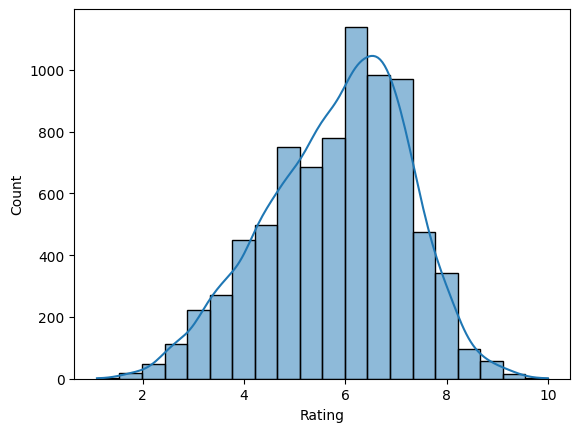

In [7]:
sns.histplot(df["Rating"], bins=20, kde=True)

In [8]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [9]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [10]:
# filling the missing values in the "Genre" column with the  unknown value "Unknown"
df.loc[:, "Genre"] = df["Genre"].fillna("Unknown")

In [11]:
# filling the missing values in the "Director", "Actor 1", "Actor 2", and "Actor 3" columns with the unknown value "Unknown"
df.loc[:, ["Director", "Actor 1", "Actor 2", "Actor 3"]] = df[["Director", "Actor 1", "Actor 2", "Actor 3"]].fillna("Unknown")

In [12]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64

In [13]:
# dropping the "Duration" column since it has a lot of missing values and is not very useful for predicting the rating
df = df.drop(columns=["Duration"])

In [14]:
df.head()

,Name,Year,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


<Axes: xlabel='Rating'>

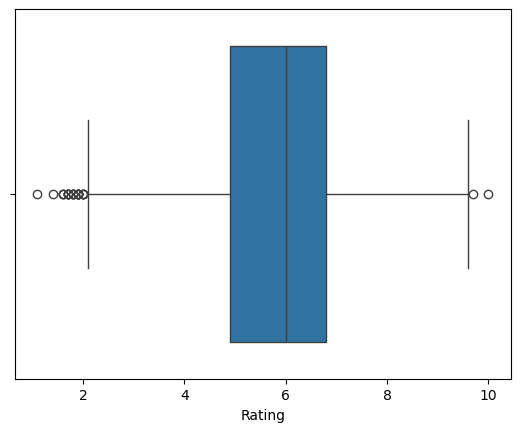

In [15]:
sns.boxplot(x=df["Rating"])

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop(columns=["Name", "Votes","Year"], inplace= True)

In [18]:
df["Genre"] = df["Genre"].str.replace(", ", ",", regex=False)

In [19]:
genre_dummies = df["Genre"].str.get_dummies(sep=",")

In [20]:
df= pd.concat([df, genre_dummies], axis = 1)
df = df.drop(columns=["Genre"])

In [21]:
print("Directors:", df["Director"].nunique())
print("Actor 1:", df["Actor 1"].nunique())
print("Actor 2:", df["Actor 2"].nunique())
print("Actor 3:", df["Actor 3"].nunique())

Directors: 3140
Actor 1: 2552
Actor 2: 2874
Actor 3: 3065


In [22]:
director_freq = df["Director"].value_counts()

df["Director_freq"] = df["Director"].map(director_freq)

In [23]:
actor1_freq = df["Actor 1"].value_counts()
actor2_freq = df["Actor 2"].value_counts()
actor3_freq = df["Actor 3"].value_counts()

df["Actor1_freq"] = df["Actor 1"].map(actor1_freq)
df["Actor2_freq"] = df["Actor 2"].map(actor2_freq)
df["Actor3_freq"] = df["Actor 3"].map(actor3_freq)

In [24]:
# here y is the target and X are the features
X = df.drop("Rating", axis = 1)
y = df["Rating"]

In [25]:
# splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [26]:
print(X_test.shape)
print(X_train.shape)
print(y_test.shape)
print(y_train.shape)

(1584, 31)
(6335, 31)
(1584,)
(6335,)


In [27]:
for col in ["Director", "Actor 1", "Actor 2", "Actor 3"]:
    freq = X_train[col].value_counts()
    
    X_train[col + "_freq"] = X_train[col].map(freq)
    X_test[col + "_freq"] = X_test[col].map(freq)

In [28]:
for col in ["Director", "Actor 1", "Actor 2", "Actor 3"]:
    freq = X_train[col].value_counts()
    
    X_train[col + "_freq"] = X_train[col].map(freq)
    X_test[col + "_freq"] = X_test[col].map(freq).fillna(0)

In [29]:
categorical_cols = ["Director", "Actor 1", "Actor 2", "Actor 3"]

X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = {}

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

results

{'Linear Regression': {'MAE': 1.0157148682858423,
  'RMSE': np.float64(1.268479757575633),
  'R²': 0.13452647660255368},
 'Random Forest': {'MAE': 1.005139333985968,
  'RMSE': np.float64(1.2584747605393256),
  'R²': 0.14812529248407558},
 'Gradient Boosting': {'MAE': 0.9773005806378444,
  'RMSE': np.float64(1.2284544964650315),
  'R²': 0.188282605324942}}

In [32]:
results_df = pd.DataFrame(results).T

print(results_df)

                        MAE      RMSE        R²
Linear Regression  1.015715  1.268480  0.134526
Random Forest      1.005139  1.258475  0.148125
Gradient Boosting  0.977301  1.228454  0.188283


# MAE
MAE tells you the average absolute prediction error.

For example:

MAE = 0.60

means that, on average, your prediction differs from the actual rating by about 0.60 rating points.

Lower is better.

# RMSE

RMSE is similar to MAE but penalizes large errors more heavily.

RMSE = 0.80

means your model's typical error, with greater emphasis on larger mistakes, is around 0.80 rating points.

Lower is better.

# R²

R² tells you how much of the variation in movie ratings is explained by the model.

For example:

R² = 0.58

means the model explains approximately 58% of the variation in the target in that test set.

Higher is better.